# Heart Disease Analysis

**Course:** BMDS2003 Data Science  
**Task:** Binary classification of Heart Disease Status

## Project Objective

The objective is to examine whether the available demographic, lifestyle, and health variables can predict **Heart Disease Status** (`Yes` or `No`).

Three classification models are compared:

1. Logistic Regression — baseline model
2. Support Vector Machine (RBF SVM)
3. Random Forest

The target is imbalanced, so accuracy is considered together with precision, recall, F1-score, ROC-AUC, and PR-AUC.

## Import Libraries

The libraries below are used for data handling, graphs, model training, and evaluation.

In [1]:
%matplotlib inline

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.svm import SVC
from scipy.stats import chi2_contingency

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

## Load Dataset

The analysis starts from the raw CSV file. No prepared result tables or saved graphs are loaded.

In [2]:
# Check common dataset locations
possible_data_paths = [
    Path("data/raw/heart_disease.csv"),
    Path("../data/raw/heart_disease.csv"),
    Path("heart_disease.csv"),
]

data_path = next((path.resolve() for path in possible_data_paths if path.exists()), None)
if data_path is None:
    checked_paths = "\n".join(str(path.resolve()) for path in possible_data_paths)
    raise FileNotFoundError(f"heart_disease.csv was not found. Checked:\n{checked_paths}")

if data_path.parent.name == "raw" and data_path.parent.parent.name == "data":
    project_folder = data_path.parents[2]
else:
    project_folder = Path.cwd()

output_folder = project_folder / "outputs" / "notebook_review"
figure_folder = output_folder / "figures"
table_folder = output_folder / "tables"
model_folder = project_folder / "models" / "notebook_review"

figure_folder.mkdir(parents=True, exist_ok=True)
table_folder.mkdir(parents=True, exist_ok=True)
model_folder.mkdir(parents=True, exist_ok=True)

print("Dataset:", data_path)
print("Output folder:", output_folder)

Dataset: C:\Users\User\Downloads\Group2_RDSY2S1_DataScienceProject\data\raw\heart_disease.csv
Output folder: C:\Users\User\Downloads\Group2_RDSY2S1_DataScienceProject\outputs\notebook_review


In [3]:
df = pd.read_csv(data_path)
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.000,Male,153.000,155.000,High,Yes,Yes,No,24.992,Yes,Yes,No,High,Medium,7.633,Medium,342.000,NaN,12.969,12.387,No
1,69.000,Female,146.000,286.000,High,No,Yes,Yes,25.222,No,Yes,No,Medium,High,8.744,Medium,133.000,157.000,9.355,19.299,No
2,46.000,Male,126.000,216.000,Low,No,No,No,29.855,No,Yes,Yes,Low,Low,4.440,Low,393.000,92.000,12.710,11.231,No
3,32.000,Female,122.000,293.000,High,Yes,Yes,No,24.130,Yes,No,Yes,Low,High,5.249,High,293.000,94.000,12.509,5.962,No
4,60.000,Male,166.000,242.000,Low,Yes,Yes,Yes,20.486,Yes,No,No,Low,High,7.031,High,263.000,154.000,10.381,8.154,No


### Dataset Size

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 21


### Data Types

In [5]:
df.dtypes.to_frame("Data Type")

,Data Type
Age,float64
Gender,object
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,object
Smoking,object
Family Heart Disease,object
Diabetes,object
BMI,float64
High Blood Pressure,object


### Summary Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9971.000,49.296,18.194,18.000,34.000,49.000,65.000,80.000
Blood Pressure,9981.000,149.758,17.573,120.000,134.000,150.000,165.000,180.000
Cholesterol Level,9970.000,225.426,43.576,150.000,187.000,226.000,263.000,300.000
BMI,9978.000,29.077,6.307,18.003,23.658,29.079,34.520,39.997
Sleep Hours,9975.000,6.991,1.753,4.001,5.450,7.003,8.532,10.000
Triglyceride Level,9974.000,250.734,87.067,100.000,176.000,250.000,326.000,400.000
Fasting Blood Sugar,9978.000,120.142,23.584,80.000,99.000,120.000,141.000,160.000
CRP Level,9974.000,7.472,4.340,0.004,3.674,7.472,11.256,14.997
Homocysteine Level,9980.000,12.456,4.323,5.000,8.723,12.409,16.141,19.999


## Data Quality

First, duplicate records and missing values are checked. Missing values are not filled before the train-test split because preprocessing must be learned from training data only.

In [7]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_values / len(df) * 100,
})
missing_table = missing_table[missing_table["Missing Values"] > 0]
missing_table.to_csv(table_folder / "missing_values.csv")
missing_table

Duplicate rows: 0


,Missing Values,Missing Percentage
Alcohol Consumption,2586,25.860
Cholesterol Level,30,0.300
Sugar Consumption,30,0.300
Diabetes,30,0.300
Age,29,0.290
High LDL Cholesterol,26,0.260
CRP Level,26,0.260
Triglyceride Level,26,0.260
High Blood Pressure,26,0.260
Sleep Hours,25,0.250


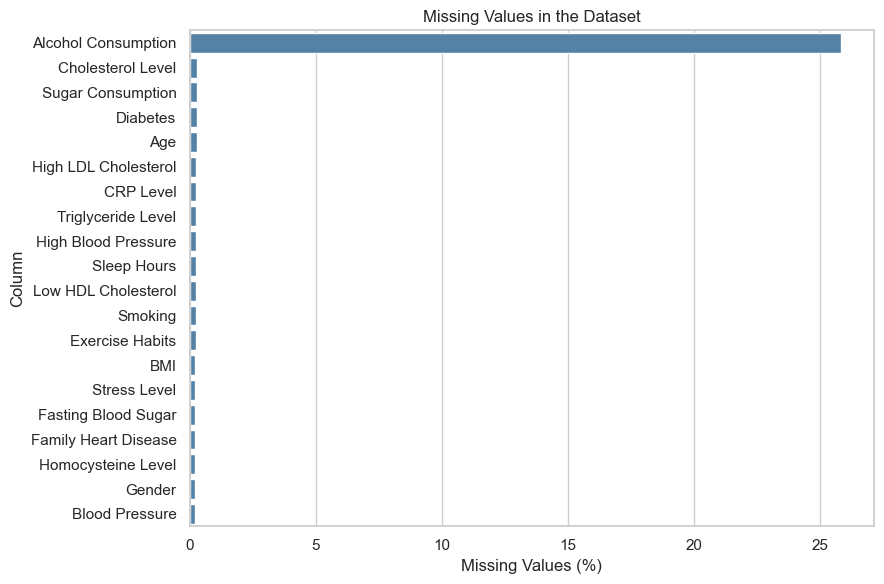

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=missing_table.reset_index(),
    x="Missing Percentage",
    y="index",
    color="steelblue",
    ax=ax,
)
ax.set_title("Missing Values in the Dataset")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Column")
fig.tight_layout()
fig.savefig(figure_folder / "missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

`Alcohol Consumption` has much more missing data than the other variables. Its missing values will be kept as a separate `Missing` category. Numerical missing values will be replaced by the training median inside each model pipeline.

### Target Distribution

The target class is checked before modelling because an imbalanced target can make accuracy misleading.

In [9]:
target_column = "Heart Disease Status"
target_counts = df[target_column].value_counts().reindex(["No", "Yes"])
target_table = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_counts / len(df) * 100,
})
target_table.to_csv(table_folder / "target_distribution.csv")
target_table

,Count,Percentage
Heart Disease Status,,
No,8000,80.000
Yes,2000,20.000


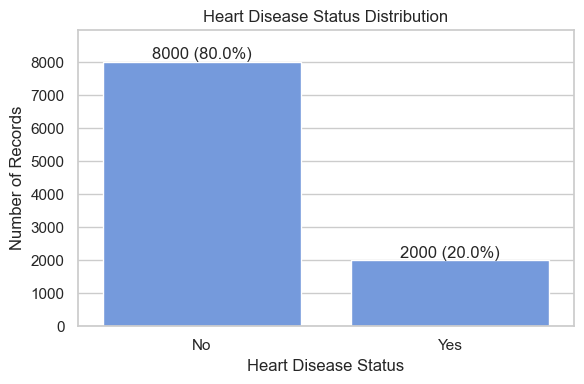

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, color="cornflowerblue", ax=ax)
ax.set_title("Heart Disease Status Distribution")
ax.set_xlabel("Heart Disease Status")
ax.set_ylabel("Number of Records")

for index, count in enumerate(target_counts.values):
    percentage = count / len(df) * 100
    ax.text(index, count + 80, f"{count} ({percentage:.1f}%)", ha="center")

ax.set_ylim(0, target_counts.max() * 1.12)
fig.tight_layout()
fig.savefig(figure_folder / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The dataset contains 80% `No` and 20% `Yes`. A model that always predicts `No` would already obtain 80% accuracy, so recall and the ranking metrics must also be examined.

### Outlier Check

The IQR rule from the lecture notes is used to check numerical variables. An observation is flagged when it is below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. Extreme values are not removed automatically because they may be genuine health measurements.

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_rows = []

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_limit) | (df[column] > upper_limit)).sum()
    outlier_rows.append([column, lower_limit, upper_limit, outlier_count])

outlier_table = pd.DataFrame(
    outlier_rows,
    columns=["Column", "Lower Limit", "Upper Limit", "IQR Outliers"],
)
outlier_table.to_csv(table_folder / "outlier_summary.csv", index=False)
outlier_table

,Column,Lower Limit,Upper Limit,IQR Outliers
0,Age,-12.500,111.500,0
1,Blood Pressure,87.500,211.500,0
2,Cholesterol Level,73.000,377.000,0
3,BMI,7.365,50.813,0
4,Sleep Hours,0.827,13.154,0
5,Triglyceride Level,-49.000,551.000,0
6,Fasting Blood Sugar,36.000,204.000,0
7,CRP Level,-7.698,22.628,0
8,Homocysteine Level,-2.403,27.266,0


The IQR check does not identify numerical outliers in this dataset, so no rows are removed.

## Exploratory Data Analysis

The following graphs are calculated directly from `df` and displayed in the notebook.

### Numerical Distributions

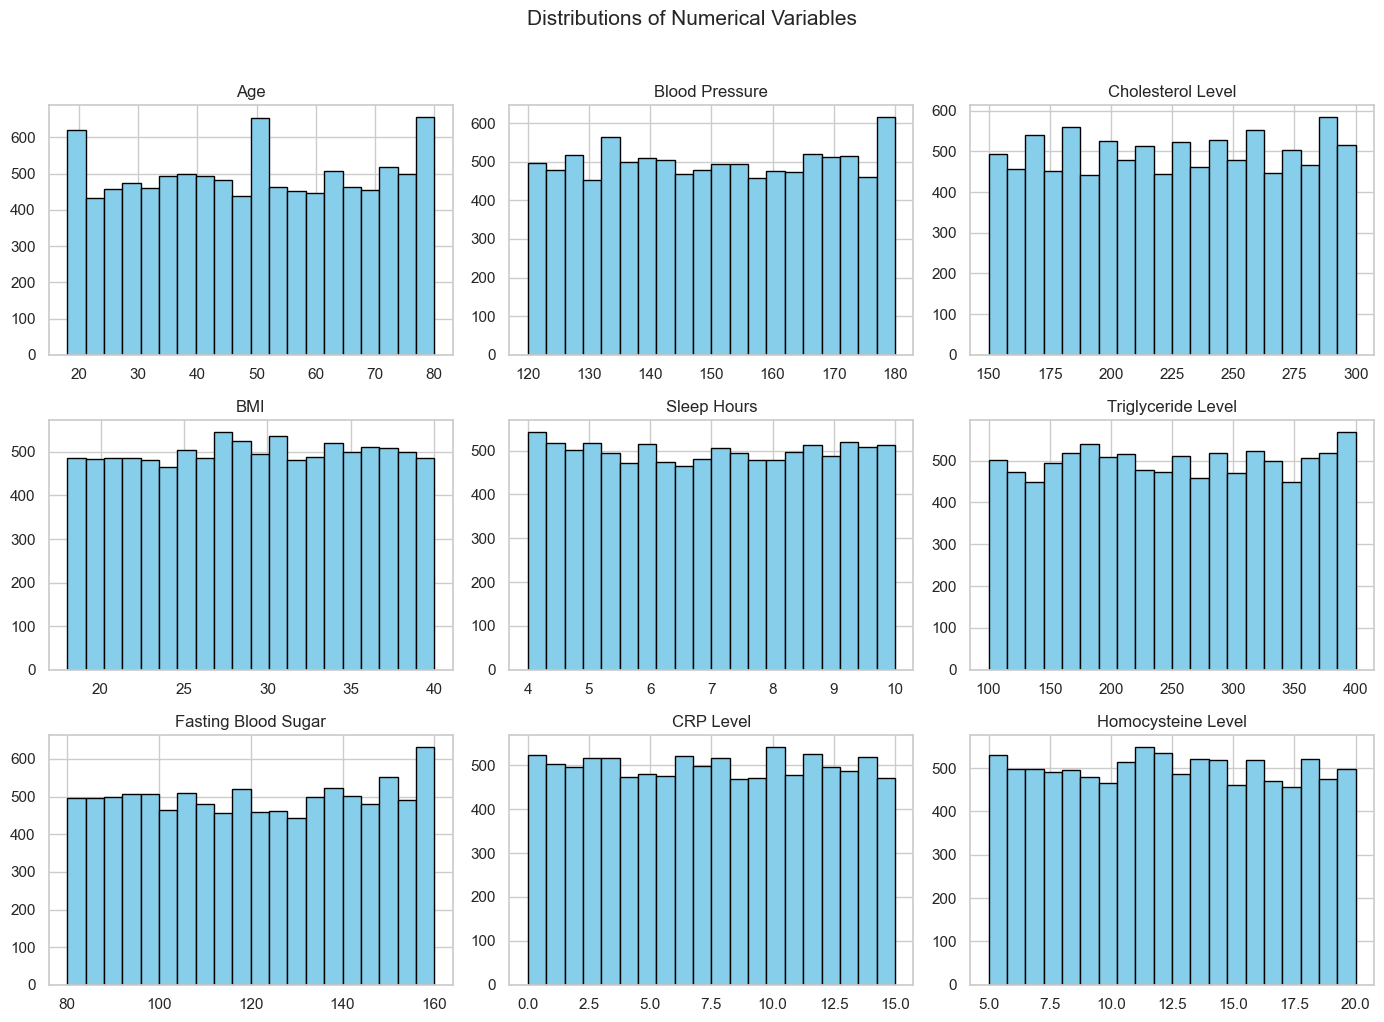

In [12]:
axes = df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20,
    color="skyblue",
    edgecolor="black",
)
fig = axes[0, 0].figure
fig.suptitle("Distributions of Numerical Variables", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(figure_folder / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

The numerical variables cover their stated ranges quite evenly. There are no obvious isolated values or strongly skewed peaks.

### Numerical Boxplots

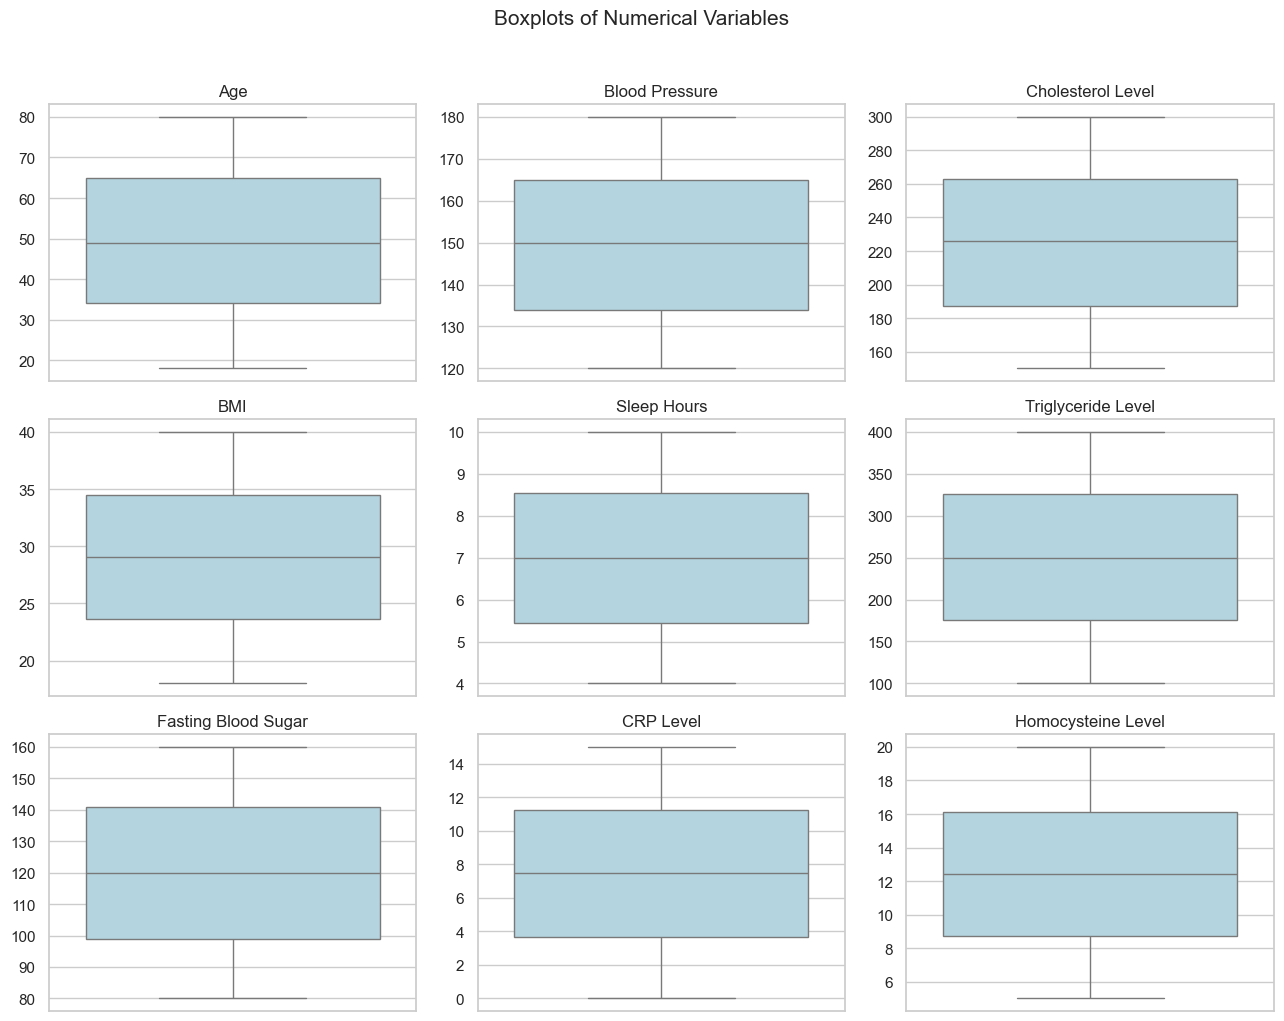

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for index, column in enumerate(numeric_columns):
    sns.boxplot(y=df[column], color="lightblue", ax=axes[index])
    axes[index].set_title(column)
    axes[index].set_ylabel("")

for index in range(len(numeric_columns), len(axes)):
    axes[index].set_visible(False)

fig.suptitle("Boxplots of Numerical Variables", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(figure_folder / "numeric_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Correlation Heatmap

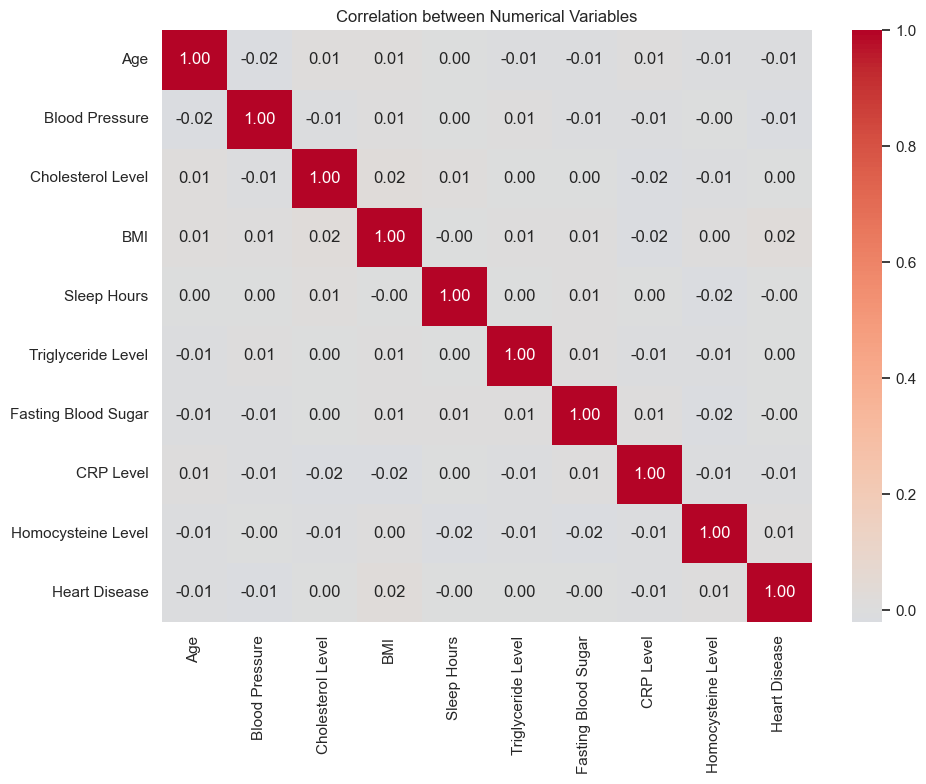

In [14]:
numeric_data = df[numeric_columns].copy()
numeric_data["Heart Disease"] = df[target_column].map({"No": 0, "Yes": 1})
corr = numeric_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation between Numerical Variables")
fig.tight_layout()
fig.savefig(figure_folder / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

The correlations with Heart Disease are close to zero. This is an early indication that the available numerical variables may contain weak predictive information.

### Numerical Variables by Target Class

The mean of each numerical variable is compared between the `No` and `Yes` groups. This helps check whether the two classes have noticeably different numerical patterns.

In [15]:
numeric_by_target = df.groupby(target_column)[numeric_columns].mean().T
numeric_by_target["Difference (Yes - No)"] = numeric_by_target["Yes"] - numeric_by_target["No"]
numeric_by_target.to_csv(table_folder / "numeric_by_target.csv")
numeric_by_target.round(3)

Heart Disease Status,No,Yes,Difference (Yes - No)
Age,49.380,48.960,-0.421
Blood Pressure,149.880,149.270,-0.610
Cholesterol Level,225.367,225.662,0.295
BMI,29.015,29.326,0.310
Sleep Hours,6.995,6.978,-0.017
Triglyceride Level,250.607,251.244,0.636
Fasting Blood Sugar,120.169,120.036,-0.133
CRP Level,7.485,7.420,-0.065
Homocysteine Level,12.438,12.528,0.090


The group means are very similar. The small differences are consistent with the weak correlations observed earlier.

### Numerical Distributions by Target Class

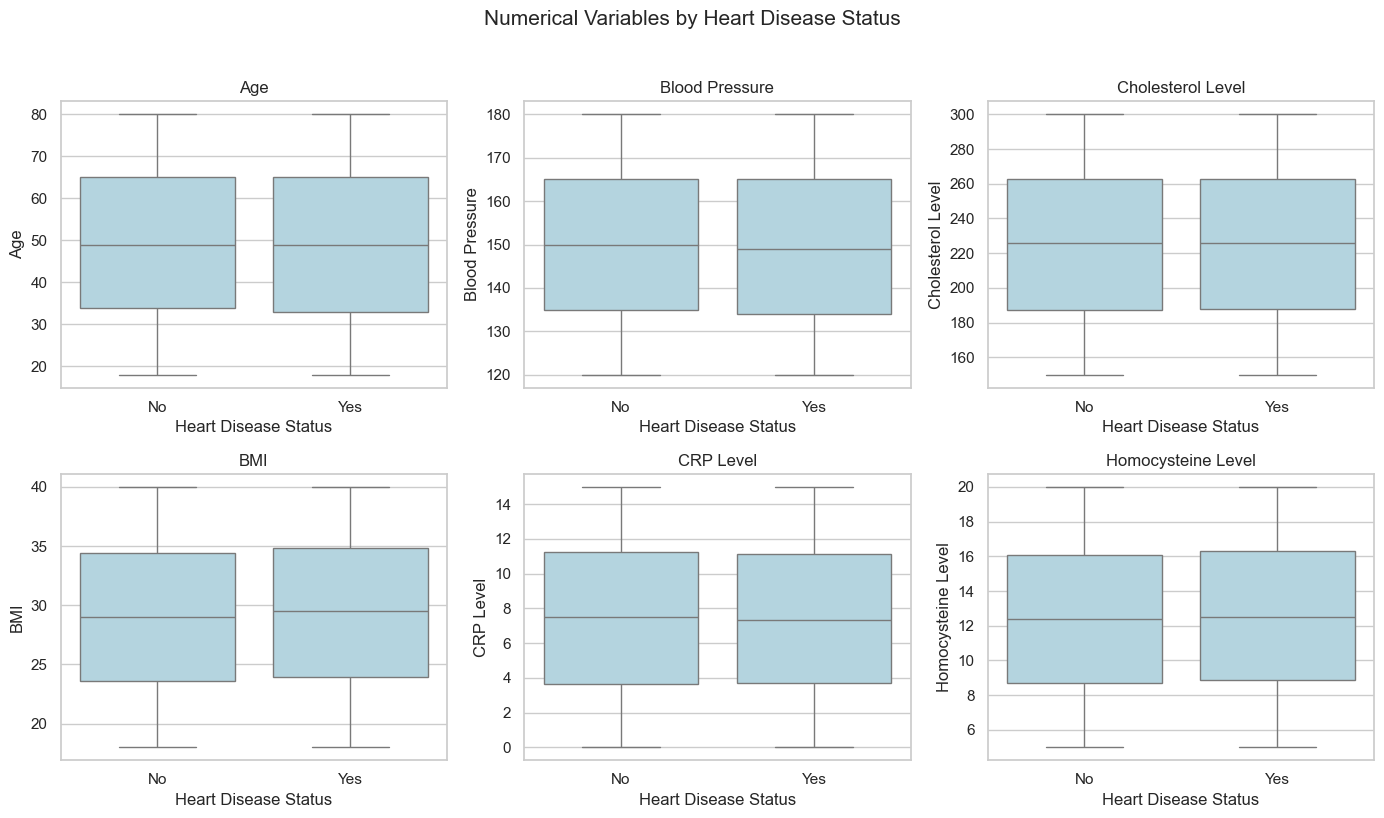

In [16]:
selected_numerical = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "CRP Level",
    "Homocysteine Level",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, column in zip(axes, selected_numerical):
    sns.boxplot(data=df, x=target_column, y=column, color="lightblue", ax=ax)
    ax.set_title(column)
    ax.set_xlabel("Heart Disease Status")

fig.suptitle("Numerical Variables by Heart Disease Status", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(figure_folder / "numeric_by_target_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

The boxplots overlap strongly for both target classes. This supports the conclusion that these variables do not separate the classes clearly.

### Selected Categorical Variables and Target Rate

The average of the encoded target gives the percentage of `Yes` cases in each category.

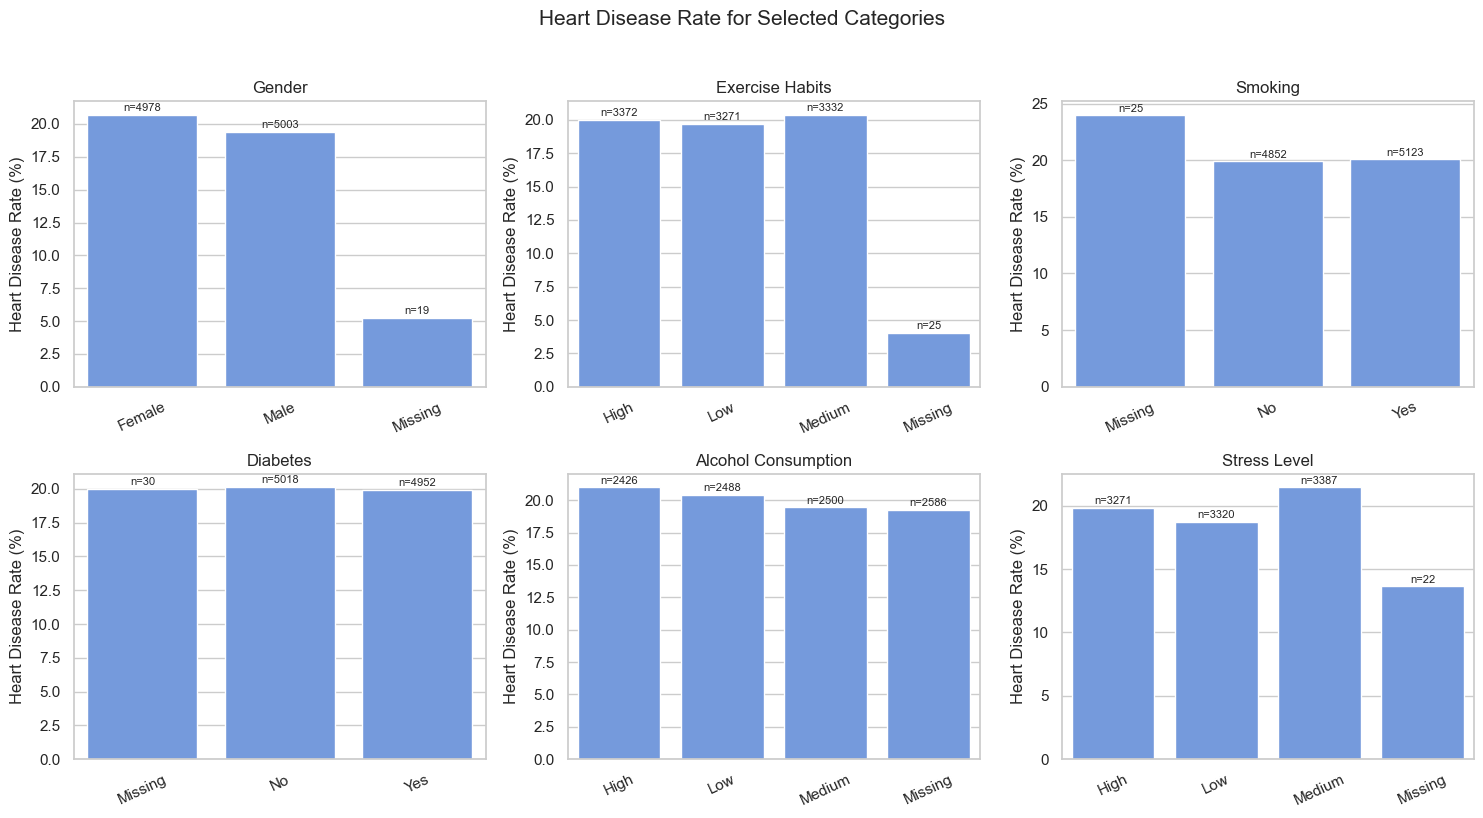

In [17]:
selected_categories = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Diabetes",
    "Alcohol Consumption",
    "Stress Level",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, selected_categories):
    plot_data = df[[column, target_column]].copy()
    plot_data[column] = plot_data[column].fillna("Missing")
    plot_data["Heart Disease Rate"] = plot_data[target_column].map({"No": 0, "Yes": 1})
    rate = plot_data.groupby(column)["Heart Disease Rate"].agg(["mean", "size"]).reset_index()
    rate["Heart Disease Rate"] = rate["mean"] * 100
    rate = rate.rename(columns={"size": "Records"})

    sns.barplot(data=rate, x=column, y="Heart Disease Rate", color="cornflowerblue", ax=ax)
    for bar, records in zip(ax.patches, rate["Records"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"n={records}", ha="center", fontsize=8)

    ax.set_title(column)
    ax.set_xlabel("")
    ax.set_ylabel("Heart Disease Rate (%)")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Heart Disease Rate for Selected Categories", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(figure_folder / "categorical_target_rates.png", dpi=150, bbox_inches="tight")
plt.show()

The observed categories are generally close to the overall 20% rate. Some `Missing` groups have different rates, but they contain only about 20–30 records and should be interpreted carefully.

### Categorical Association Check

A chi-square test is used as an exploratory check of the relationship between each categorical feature and the target. A small p-value does not automatically mean that a feature has strong predictive value.

In [18]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.drop(target_column)
association_rows = []

for column in categorical_columns:
    check_data = df[[column, target_column]].copy()
    check_data[column] = check_data[column].fillna("Missing")
    table = pd.crosstab(check_data[column], check_data[target_column])
    chi_square, p_value, degrees_of_freedom, expected = chi2_contingency(table)
    association_rows.append({
        "Feature": column,
        "Chi-square": chi_square,
        "Degrees of Freedom": degrees_of_freedom,
        "p-value": p_value,
    })

categorical_association = pd.DataFrame(association_rows).sort_values("p-value")
categorical_association.to_csv(table_folder / "categorical_association.csv", index=False)
categorical_association.round(4)

,Feature,Chi-square,Degrees of Freedom,p-value
9,Stress Level,8.288,3,0.040
0,Gender,5.312,2,0.070
1,Exercise Habits,4.460,3,0.216
3,Family Heart Disease,2.802,2,0.246
10,Sugar Consumption,3.208,3,0.361
8,Alcohol Consumption,3.207,3,0.361
6,Low HDL Cholesterol,1.306,2,0.520
7,High LDL Cholesterol,0.973,2,0.615
2,Smoking,0.311,2,0.856
4,Diabetes,0.073,2,0.964


Most categorical variables do not show evidence of a strong relationship with the target. Any isolated small p-value should be treated cautiously because several exploratory tests were performed.

## Data Preparation

The target is converted to `0` and `1`. A stratified 80/20 split keeps the same class proportions in the training and test sets. The test set is kept untouched until final evaluation.

In [19]:
X = df.drop(columns=target_column)
y = df[target_column].map({"No": 0, "Yes": 1})

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

split_table = pd.DataFrame({
    "Rows": [len(X_train), len(X_test)],
    "Heart Disease Rate (%)": [y_train.mean() * 100, y_test.mean() * 100],
}, index=["Training", "Test"])
split_table.to_csv(table_folder / "split_summary.csv")
split_table

,Rows,Heart Disease Rate (%)
Training,8000,20.000
Test,2000,20.000


The same preprocessing steps are placed inside each pipeline. This means the imputer, encoder, and scaler are fitted separately inside every training fold, which prevents data leakage.

In [20]:
numerical_steps = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])

categorical_steps = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numerical_steps, numerical_features),
    ("categorical", categorical_steps, categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 9
Categorical features: 11


## Majority-Class Reference

Before the three formal models, a simple reference predicts the most common class for every record. It is included only as a sanity check and **does not count as one of the three assignment models**.

In [21]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_prediction = dummy_model.predict(X_test)
dummy_score = dummy_model.predict_proba(X_test)[:, 1]

dummy_reference = pd.DataFrame([{
    "Reference": "Always predict No",
    "Accuracy": accuracy_score(y_test, dummy_prediction),
    "Precision": precision_score(y_test, dummy_prediction, zero_division=0),
    "Recall": recall_score(y_test, dummy_prediction),
    "F1-score": f1_score(y_test, dummy_prediction, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, dummy_score),
    "PR-AUC": average_precision_score(y_test, dummy_score),
}])

dummy_reference.to_csv(table_folder / "majority_class_reference.csv", index=False)
dummy_reference.round(3)

,Reference,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Always predict No,0.800,0.000,0.000,0.000,0.500,0.200


The reference obtains 80% accuracy but has zero recall for Heart Disease. This confirms that accuracy alone is not suitable for judging the three models.

## Model 1: Logistic Regression (Formal Baseline)

Among the three assignment models, Logistic Regression is the formal baseline. It is simple, interpretable, and suitable for binary classification. The separate majority-class reference above is only a sanity check and is not counted as a model.

In [22]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=42)),
])

logistic_parameters = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}
assert len(list(ParameterGrid(logistic_parameters))) == 8

start_time = time.time()
logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_parameters,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    error_score="raise",
)
logistic_search.fit(X_train, y_train)

print("Candidates:", len(logistic_search.cv_results_["params"]))
print("Best parameters:", logistic_search.best_params_)
print(f"Best CV ROC-AUC: {logistic_search.best_score_:.3f}")
print(f"Training time: {time.time() - start_time:.1f} seconds")

Candidates: 8
Best parameters: {'model__C': 10, 'model__class_weight': 'balanced'}
Best CV ROC-AUC: 0.514
Training time: 3.9 seconds


## Model 2: RBF Support Vector Machine

The SVM uses scaled data and an RBF kernel, following the practical example. Four values of `C` and two `gamma` settings are compared. Balanced class weights are fixed because only 20% of records belong to the positive class.

In [23]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", class_weight="balanced", random_state=42)),
])

svm_parameters = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto"],
}
assert len(list(ParameterGrid(svm_parameters))) == 8

start_time = time.time()
svm_search = GridSearchCV(
    svm_pipeline,
    svm_parameters,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    error_score="raise",
)
svm_search.fit(X_train, y_train)

print("Candidates:", len(svm_search.cv_results_["params"]))
print("Best parameters:", svm_search.best_params_)
print(f"Best CV ROC-AUC: {svm_search.best_score_:.3f}")
print(f"Training time: {time.time() - start_time:.1f} seconds")

Candidates: 8
Best parameters: {'model__C': 100, 'model__gamma': 'scale'}
Best CV ROC-AUC: 0.511
Training time: 206.9 seconds


## Model 3: Random Forest

Random Forest combines many decision trees. The parameter grid is based on the tree settings demonstrated in Practical 5b. Balanced class weights are used because the positive class is smaller.

In [24]:
forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1)),
])

forest_parameters = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 4],
}
assert len(list(ParameterGrid(forest_parameters))) == 8

start_time = time.time()
forest_search = GridSearchCV(
    forest_pipeline,
    forest_parameters,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    error_score="raise",
)
forest_search.fit(X_train, y_train)

print("Candidates:", len(forest_search.cv_results_["params"]))
print("Best parameters:", forest_search.best_params_)
print(f"Best CV ROC-AUC: {forest_search.best_score_:.3f}")
print(f"Training time: {time.time() - start_time:.1f} seconds")

Candidates: 8
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.521
Training time: 77.4 seconds


## Cross-Validation Results

The complete search contains 24 configurations: 8 for each model. Only the best settings are used on the untouched test set.

In [25]:
searches = {
    "Logistic Regression": logistic_search,
    "SVM": svm_search,
    "Random Forest": forest_search,
}

grid_tables = []
best_parameter_rows = []

for model_name, search in searches.items():
    result = pd.DataFrame(search.cv_results_)
    result = result[["params", "mean_test_score", "std_test_score", "rank_test_score"]].copy()
    result.insert(0, "Model", model_name)
    result = result.rename(columns={
        "params": "Parameters",
        "mean_test_score": "Mean CV ROC-AUC",
        "std_test_score": "CV Standard Deviation",
        "rank_test_score": "Rank",
    })
    grid_tables.append(result)
    best_parameter_rows.append({
        "Model": model_name,
        "Best Parameters": str(search.best_params_),
        "Best CV ROC-AUC": search.best_score_,
    })

grid_results = pd.concat(grid_tables, ignore_index=True)
best_parameters = pd.DataFrame(best_parameter_rows)

grid_results.to_csv(table_folder / "grid_search_results.csv", index=False)
best_parameters.to_csv(table_folder / "best_parameters.csv", index=False)
best_parameters.round(3)

,Model,Best Parameters,Best CV ROC-AUC
0,Logistic Regression,"{'model__C': 10, 'model__class_weight': 'balan...",0.514
1,SVM,"{'model__C': 100, 'model__gamma': 'scale'}",0.511
2,Random Forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.521


## Test Set Evaluation

The test set is evaluated once using each tuned pipeline. For SVM, the decision score is used for ROC and precision-recall curves; the other two models provide predicted probabilities.

In [26]:
models = {
    "Logistic Regression": logistic_search.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Random Forest": forest_search.best_estimator_,
}

predictions = {}
model_scores = {}
metric_rows = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    if model_name == "SVM":
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp)

    predictions[model_name] = y_pred
    model_scores[model_name] = y_score
    metric_rows.append({
        "Model": model_name,
        "CV ROC-AUC": searches[model_name].best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score),
    })

model_results = pd.DataFrame(metric_rows).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
model_results.to_csv(table_folder / "model_results.csv", index=False)
model_results.round(3)

,Model,CV ROC-AUC,Accuracy,Precision,Recall,Specificity,F1-score,Test ROC-AUC,PR-AUC
0,Random Forest,0.521,0.776,0.195,0.038,0.961,0.063,0.490,0.197
1,Logistic Regression,0.514,0.500,0.190,0.460,0.510,0.269,0.487,0.196
2,SVM,0.511,0.698,0.225,0.208,0.821,0.216,0.507,0.207


### Classification Reports

In [27]:
for model_name in models:
    print()
    print(model_name)
    report = classification_report(
        y_test,
        predictions[model_name],
        target_names=["No", "Yes"],
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report).T.round(3))


Logistic Regression


,precision,recall,f1-score,support
No,0.791,0.510,0.620,1600.000
Yes,0.190,0.460,0.269,400.000
accuracy,0.500,0.500,0.500,0.500
macro avg,0.490,0.485,0.445,2000.000
weighted avg,0.671,0.500,0.550,2000.000



SVM


,precision,recall,f1-score,support
No,0.806,0.821,0.813,1600.000
Yes,0.225,0.208,0.216,400.000
accuracy,0.698,0.698,0.698,0.698
macro avg,0.515,0.514,0.515,2000.000
weighted avg,0.689,0.698,0.694,2000.000



Random Forest


,precision,recall,f1-score,support
No,0.800,0.961,0.873,1600.000
Yes,0.195,0.038,0.063,400.000
accuracy,0.776,0.776,0.776,0.776
macro avg,0.497,0.499,0.468,2000.000
weighted avg,0.679,0.776,0.711,2000.000


### Model Comparison

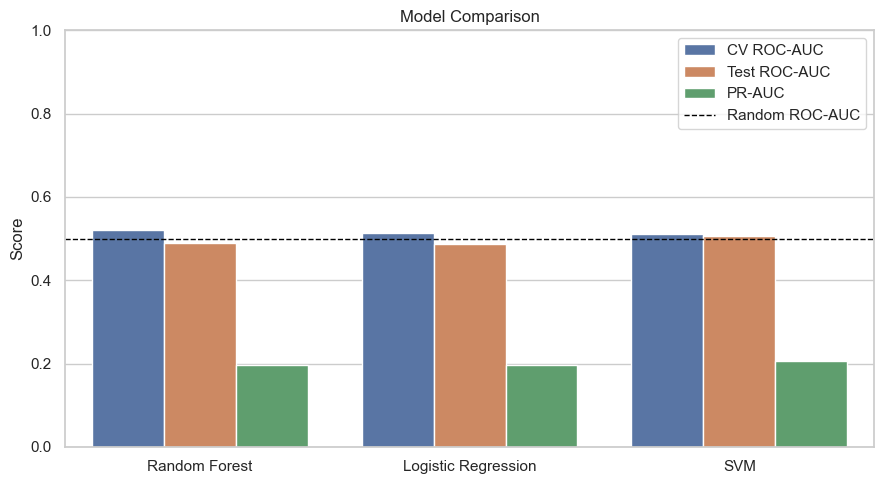

In [28]:
comparison_data = model_results.melt(
    id_vars="Model",
    value_vars=["CV ROC-AUC", "Test ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comparison_data, x="Model", y="Score", hue="Metric", ax=ax)
ax.axhline(0.50, color="black", linestyle="--", linewidth=1, label="Random ROC-AUC")
ax.set_title("Model Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(figure_folder / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrices

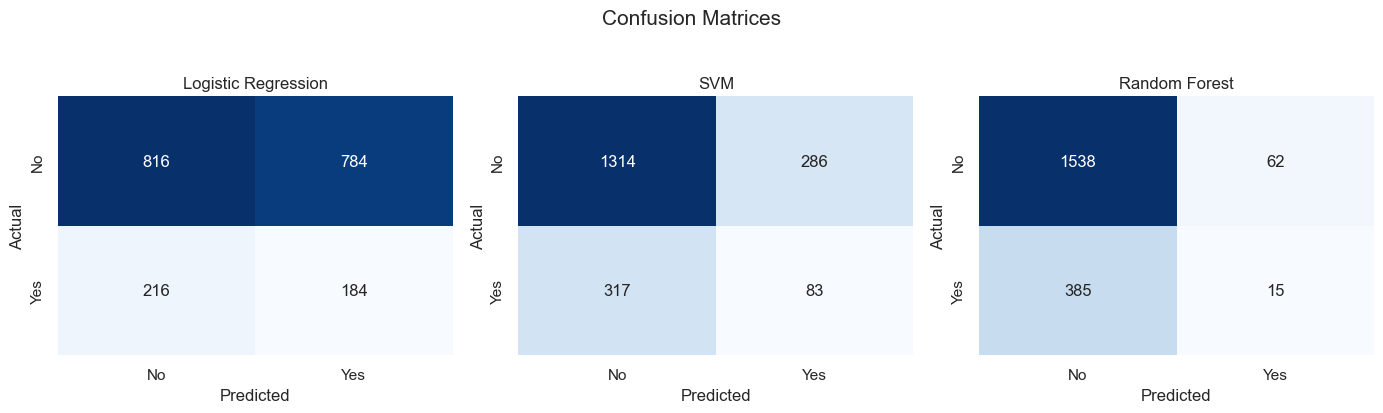

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model_name in zip(axes, models):
    matrix = confusion_matrix(y_test, predictions[model_name], labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices", fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(figure_folder / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

A high number of correct `No` predictions can produce high accuracy even when very few `Yes` cases are identified. The confusion matrices make this problem visible.

### ROC Curves

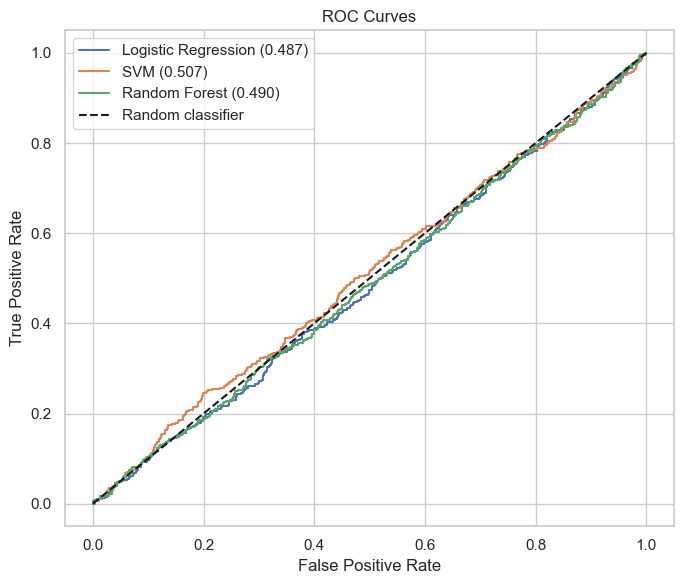

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in models:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, model_scores[model_name])
    auc_value = roc_auc_score(y_test, model_scores[model_name])
    ax.plot(false_positive_rate, true_positive_rate, label=f"{model_name} ({auc_value:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
fig.tight_layout()
fig.savefig(figure_folder / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Precision-Recall Curves

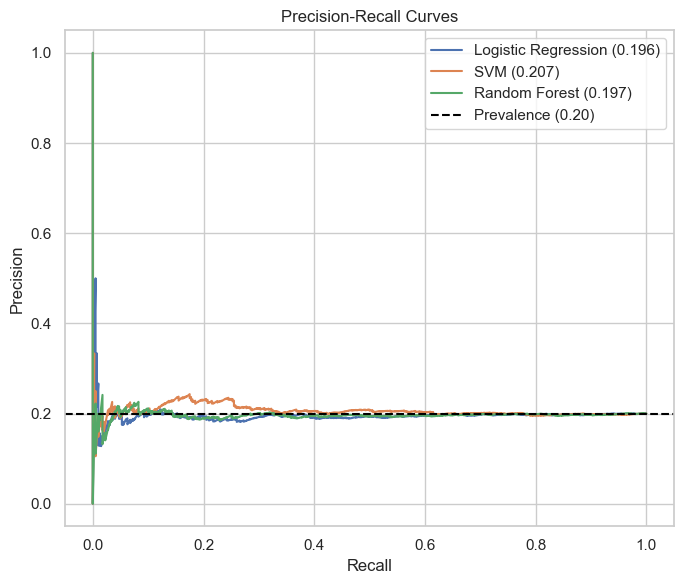

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in models:
    precision_values, recall_values, _ = precision_recall_curve(y_test, model_scores[model_name])
    pr_auc = average_precision_score(y_test, model_scores[model_name])
    ax.plot(recall_values, precision_values, label=f"{model_name} ({pr_auc:.3f})")

positive_rate = y_test.mean()
ax.axhline(positive_rate, color="black", linestyle="--", label=f"Prevalence ({positive_rate:.2f})")
ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
fig.tight_layout()
fig.savefig(figure_folder / "precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Save and Check the Models

Each tuned pipeline is saved in the separate review model folder. The saved files are immediately reloaded and checked on ten test records.

In [32]:
model_paths = {
    "Logistic Regression": model_folder / "logistic_regression.joblib",
    "SVM": model_folder / "svm.joblib",
    "Random Forest": model_folder / "random_forest.joblib",
}

for model_name, model in models.items():
    joblib.dump(model, model_paths[model_name])

best_model_name = model_results.iloc[0]["Model"]
joblib.dump(models[best_model_name], model_folder / "best_model.joblib")

reload_rows = []
for model_name, model_path in model_paths.items():
    loaded_model = joblib.load(model_path)
    same_predictions = np.array_equal(
        models[model_name].predict(X_test.head(10)),
        loaded_model.predict(X_test.head(10)),
    )
    reload_rows.append({
        "Model": model_name,
        "Saved File": model_path.name,
        "Predictions Match": same_predictions,
    })

reload_check = pd.DataFrame(reload_rows)
reload_check.to_csv(table_folder / "model_reload_check.csv", index=False)
reload_check

,Model,Saved File,Predictions Match
0,Logistic Regression,logistic_regression.joblib,True
1,SVM,svm.joblib,True
2,Random Forest,random_forest.joblib,True


## Export Model Outputs for Streamlit

This section does not retrain or change any model. It only exports the model results already calculated above so the Streamlit prototype can display the same evaluation results.


In [33]:
# Export the existing model results for the Streamlit prototype.
# No model is retrained in this cell.

import json

streamlit_output_folder = project_folder / "prototype" / "model_outputs"
streamlit_figure_folder = streamlit_output_folder / "figures"
streamlit_table_folder = streamlit_output_folder / "tables"

streamlit_figure_folder.mkdir(parents=True, exist_ok=True)
streamlit_table_folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Export result tables
# -----------------------------
model_results.to_csv(streamlit_table_folder / "model_results.csv", index=False)
best_parameters.to_csv(streamlit_table_folder / "best_parameters.csv", index=False)
dummy_reference.to_csv(streamlit_table_folder / "majority_class_reference.csv", index=False)
split_table.to_csv(streamlit_table_folder / "split_summary.csv")

classification_rows = []
confusion_output = {}

for model_name in models:
    report = classification_report(
        y_test,
        predictions[model_name],
        target_names=["No", "Yes"],
        output_dict=True,
        zero_division=0,
    )

    for label, values in report.items():
        if isinstance(values, dict):
            classification_rows.append({
                "Model": model_name,
                "Class": label,
                **values,
            })

    matrix = confusion_matrix(y_test, predictions[model_name], labels=[0, 1])
    confusion_output[model_name] = {
        "tn": int(matrix[0, 0]),
        "fp": int(matrix[0, 1]),
        "fn": int(matrix[1, 0]),
        "tp": int(matrix[1, 1]),
    }

classification_reports = pd.DataFrame(classification_rows)
classification_reports.to_csv(
    streamlit_table_folder / "classification_reports.csv",
    index=False,
)

# -----------------------------
# 2. Export Matplotlib figures
# -----------------------------
comparison_data = model_results.melt(
    id_vars="Model",
    value_vars=["CV ROC-AUC", "Test ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comparison_data, x="Model", y="Score", hue="Metric", ax=ax)
ax.axhline(0.50, color="black", linestyle="--", linewidth=1, label="Random ROC-AUC")
ax.set_title("Model Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(streamlit_figure_folder / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model_name in zip(axes, models):
    matrix = confusion_matrix(y_test, predictions[model_name], labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices", fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(streamlit_figure_folder / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
for model_name in models:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test, model_scores[model_name]
    )
    auc_value = roc_auc_score(y_test, model_scores[model_name])
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} ({auc_value:.3f})",
    )

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
fig.tight_layout()
fig.savefig(streamlit_figure_folder / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
for model_name in models:
    precision_values, recall_values, _ = precision_recall_curve(
        y_test, model_scores[model_name]
    )
    pr_auc = average_precision_score(y_test, model_scores[model_name])
    ax.plot(
        recall_values,
        precision_values,
        label=f"{model_name} ({pr_auc:.3f})",
    )

positive_rate = float(y_test.mean())
ax.axhline(
    positive_rate,
    color="black",
    linestyle="--",
    label=f"Prevalence ({positive_rate:.2f})",
)
ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
fig.tight_layout()
fig.savefig(
    streamlit_figure_folder / "precision_recall_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)

# -----------------------------
# 3. Export model metadata
# -----------------------------
selected_model_name = str(model_results.iloc[0]["Model"])
selected_row = model_results.iloc[0]

def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value

all_model_output = {}
for _, row in model_results.iterrows():
    name = str(row["Model"])
    all_model_output[name] = {
        "best_parameters": _json_safe(searches[name].best_params_),
        "cv_roc_auc": float(row["CV ROC-AUC"]),
        "accuracy": float(row["Accuracy"]),
        "precision": float(row["Precision"]),
        "recall": float(row["Recall"]),
        "specificity": float(row["Specificity"]),
        "f1_score": float(row["F1-score"]),
        "test_roc_auc": float(row["Test ROC-AUC"]),
        "pr_auc": float(row["PR-AUC"]),
        "confusion_matrix": confusion_output[name],
    }

model_metadata = {
    "model_name": selected_model_name,
    "decision_threshold": 0.5,
    "selection_rule": "Highest 5-fold training CV ROC-AUC among the three formal models",
    "best_model": {
        "name": selected_model_name,
        "display_name": selected_model_name,
        "decision_threshold": 0.5,
        "cv_roc_auc": float(selected_row["CV ROC-AUC"]),
        "metrics_default_0_5": {
            "accuracy": float(selected_row["Accuracy"]),
            "precision": float(selected_row["Precision"]),
            "recall": float(selected_row["Recall"]),
            "specificity": float(selected_row["Specificity"]),
            "f1_score": float(selected_row["F1-score"]),
            "roc_auc": float(selected_row["Test ROC-AUC"]),
            "average_precision_pr_auc": float(selected_row["PR-AUC"]),
        },
    },
    "all_models": all_model_output,
    "majority_class_reference": {
        "accuracy": float(dummy_reference.iloc[0]["Accuracy"]),
        "precision": float(dummy_reference.iloc[0]["Precision"]),
        "recall": float(dummy_reference.iloc[0]["Recall"]),
        "f1_score": float(dummy_reference.iloc[0]["F1-score"]),
        "roc_auc": float(dummy_reference.iloc[0]["ROC-AUC"]),
        "pr_auc": float(dummy_reference.iloc[0]["PR-AUC"]),
    },
    "positive_class_rate": positive_rate,
    "input_features": int(X.shape[1]),
    "source_notebook": "Heart_Disease_Analysis.ipynb",
}

with (model_folder / "model_metadata.json").open("w", encoding="utf-8") as handle:
    json.dump(model_metadata, handle, indent=2)

with (streamlit_output_folder / "model_outputs.json").open("w", encoding="utf-8") as handle:
    json.dump(model_metadata, handle, indent=2)

print("Streamlit model outputs exported to:")
print(streamlit_output_folder)
print()
print("Selected model:", selected_model_name)
print("Selection rule: highest 5-fold training CV ROC-AUC")
display(model_results.round(3))


Streamlit model outputs exported to:
C:\Users\User\Downloads\Group2_RDSY2S1_DataScienceProject\prototype\model_outputs

Selected model: Random Forest
Selection rule: highest 5-fold training CV ROC-AUC


,Model,CV ROC-AUC,Accuracy,Precision,Recall,Specificity,F1-score,Test ROC-AUC,PR-AUC
0,Random Forest,0.521,0.776,0.195,0.038,0.961,0.063,0.490,0.197
1,Logistic Regression,0.514,0.500,0.190,0.460,0.510,0.269,0.487,0.196
2,SVM,0.511,0.698,0.225,0.208,0.821,0.216,0.507,0.207


## Conclusion

In [34]:
best_cv_row = model_results.sort_values("CV ROC-AUC", ascending=False).iloc[0]
best_test_row = model_results.sort_values("Test ROC-AUC", ascending=False).iloc[0]

print(
    f"The highest cross-validation ROC-AUC is {best_cv_row['CV ROC-AUC']:.3f} "
    f"from {best_cv_row['Model']}."
)
print(
    f"The highest test ROC-AUC is {best_test_row['Test ROC-AUC']:.3f} "
    f"from {best_test_row['Model']}."
)

if model_results["Test ROC-AUC"].max() < 0.60:
    print(
        "All test ROC-AUC values are close to 0.50. "
        "This suggests that the supplied variables contain very weak predictive signal."
    )

print(
    "The models should not be treated as a diagnostic system. "
    "Future work should use better validated data, stronger predictors, and external validation."
)

The highest cross-validation ROC-AUC is 0.521 from Random Forest.
The highest test ROC-AUC is 0.507 from SVM.
All test ROC-AUC values are close to 0.50. This suggests that the supplied variables contain very weak predictive signal.
The models should not be treated as a diagnostic system. Future work should use better validated data, stronger predictors, and external validation.


The main limitation is the dataset rather than a lack of model complexity. The class distribution creates an apparently good 80% accuracy for majority-class prediction, while ROC-AUC and PR-AUC show that discrimination is close to chance. The ROC-AUC and PR-AUC results therefore indicate that this dataset has weak predictive signal.